# Convolution

Convolution is a mathematical operation that is used to transform a signal, note that the signal can be 1 dimensional (a standard signal), 2 dimensional (an image), or have higher dimensions. 

The convolution operation is defined as

$$
(f * g)(t) \equiv \int_{-\infty}^{\infty} f(\tau) g(t - \tau) d\tau
$$

Where $f$ is the input signal and $g$ is the kernel (or filter). The integral computes a weighted sum of the signal $f$, where the weights are defined by the kernel $g$ flipped and shifted by $t$.

Overall, this means that when you convolve a signal (or an image, or multidimensional object) with a kernel, you obtain a new signal that has been transformed by the kernel. 

In this notebook, we will learn the basic concepts of convolution, how it is used to transform a signal in specific ways, and the connection with Convolutional Neural Networks. 

## Learning goals
- understand what a 1D convolution does
- apply a mean smoothing filter to a signal
- see how different kernels produce different transformations
- understand stride, padding, and kernel size
- connect classical filtering to learned convolutional layers in neural networks
- build intuition for how CNNs extract useful patterns from data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

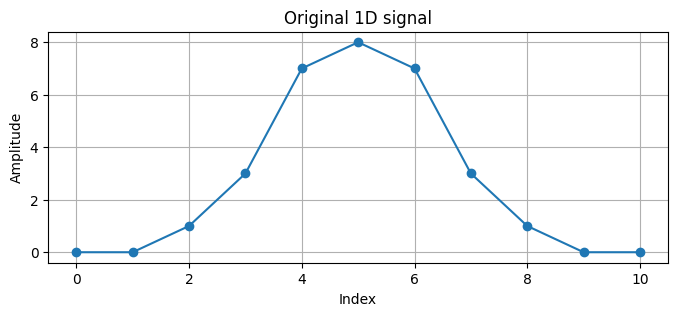

In [11]:
#we will create a simple signal and a kernel to convolve with it
x = np.array([0, 0, 1, 3, 7, 8, 7, 3, 1, 0, 0])

plt.figure(figsize=(8, 3))
plt.plot(x, marker='o')
plt.title('Original 1D signal')
plt.xlabel('Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

### What is convolution?

For a 1D signal, convolution works by:

1. placing a **kernel**, over part of the signal
2. multiplying each signal value by the corresponding filter value
3. summing the products
4. sliding the filter to the next location and repeating

We have already seen this process in action when we computed the median filter. For clarify, let us redefine the same process using the following kernel 

$$
kernel = \left[\frac{1}{3},\frac{1}{3},\frac{1}{3}\right]
$$

We will apply this filter to the signal one step at the time.

For example:

- signal window: [1, 3, 7]
- kernel: [1/3, 1/3, 1/3]
- product: [1/3, 1, 7/3]
- sum: 11/3


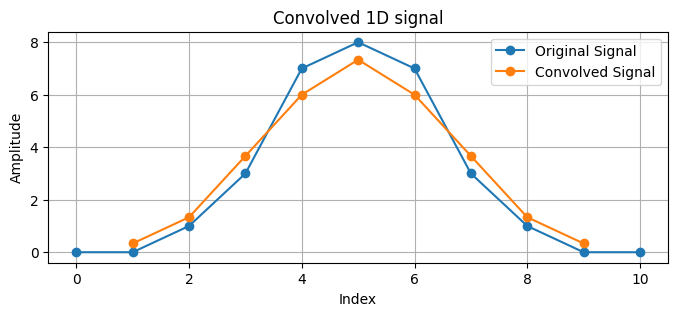

In [ ]:

x_new = np.zeros(len(x))  # we need to add zero padding to the signal to convolve with the kernel
# multiply the kernel with the signal and sum the result, 
#this operation will change the first value of the signal
x_new[1] = (x[0]*(1/3)) + (x[1]*(1/3)) + (x[2]*(1/3))

x_new[2] = (x[1]*(1/3)) + (x[2]*(1/3)) + (x[3]*(1/3))

x_new[3] = (x[2]*(1/3)) + (x[3]*(1/3)) + (x[4]*(1/3))

x_new[4] = (x[3]*(1/3)) + (x[4]*(1/3)) + (x[5]*(1/3))

x_new[5] = (x[4]*(1/3)) + (x[5]*(1/3)) + (x[6]*(1/3))

x_new[6] = (x[5]*(1/3)) + (x[6]*(1/3)) + (x[7]*(1/3))

x_new[7] = (x[6]*(1/3)) + (x[7]*(1/3)) + (x[8]*(1/3))

x_new[8] = (x[7]*(1/3)) + (x[8]*(1/3)) + (x[9]*(1/3))

x_new[9] = (x[8]*(1/3)) + (x[9]*(1/3)) + (x[10]*(1/3))

#remove the first and last value of the convolved signal, since they are not valid values
x_new = x_new[1:-1]

plt.figure(figsize=(8, 3))
plt.plot(x, marker='o', label='Original Signal')
plt.plot(np.arange(1, len(x_new)+1),x_new, marker='o', label='Convolved Signal')
plt.title('Convolved 1D signal')
plt.xlabel('Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

## What is padding?

Without padding, the output becomes shorter because the kernel cannot extend beyond the signal boundaries.

With **padding**, we add extra values around the edges so that the kernel can still be applied near the ends.

Common choices:
- no padding: output is shorter
- zero padding: add zeros at both ends
- mirror padding: mirror the signal at the extermes.

Example of zero padding 
- Original signal = `[2,1,3,7,8]`
- Padded signal = `[0,2,1,3,7,8,0]`

with padding, the output of the convolution is the same length as the original signal. 

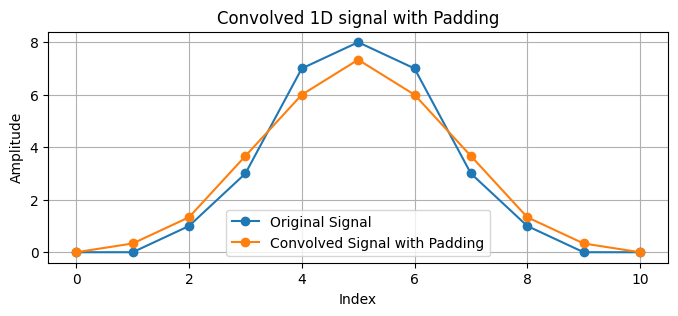

In [ ]:
#add zero padding to the original signal
x_padded = np.pad(x, (1, 1), mode='constant')
#this will add a zero at the beginning and end of the signal, which will allow us to convolve with the kernel without losing any values
x_new_padded = np.zeros(len(x_padded))
kernel = np.array([1/3, 1/3, 1/3])  # this is the kernel we will use to convolve with the signal, it is a simple moving average kernel that will smooth the signal
#convolve the padded signal with the kernel using a pre-built function from numpy
x_new_padded = np.convolve(x_padded, kernel, mode='same')
#remove the first and last value of the convolved signal, since they are not valid values
x_new_padded = x_new_padded[1:-1]   
plt.figure(figsize=(8, 3))
plt.plot(x, marker='o', label='Original Signal')
plt.plot(x_new_padded, marker='o', label='Convolved Signal with Padding')
plt.title('Convolved 1D signal with Padding')
plt.xlabel('Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()  

## What is stride?

The **stride** determines how far the kernel moves each time.

Typically, the kernel moves one point at the time, this is called stride 1. However, you can adjust the stride and have the kernel applied only to portions of the signal 

- stride = 1: move one step at a time
- stride = 2: move two steps at a time
- stride = 5: move five steps at a time


Larger stride means:
- fewer output points
- more aggressive downsampling

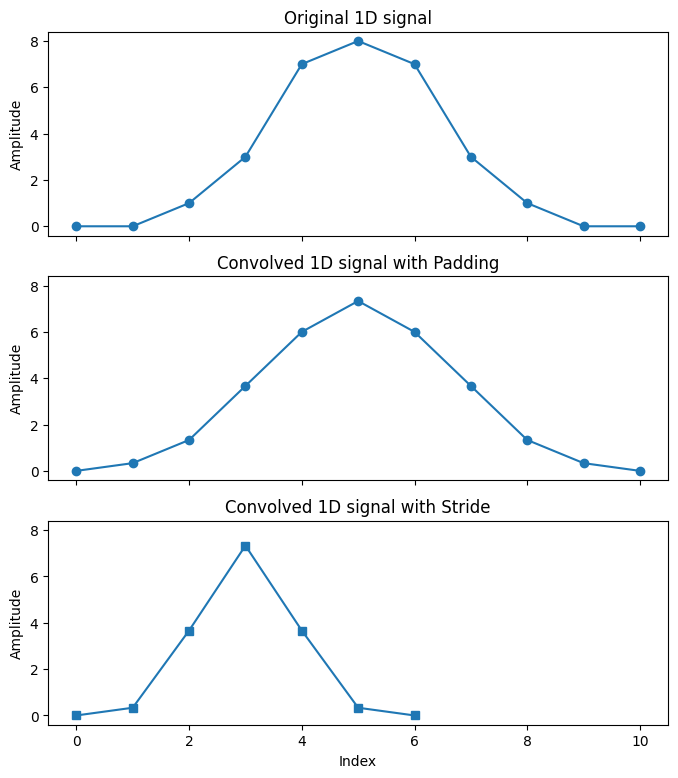

In [38]:
#add zero padding to the original signal
x_padded = np.pad(x, (1, 1), mode='constant')
#this will add a zero at the beginning and end of the signal, which will allow us to convolve with the kernel without losing any values
x_new_padded = np.zeros(len(x_padded))
kernel = np.array([1/3, 1/3, 1/3])  # this is the kernel we will use to convolve with the signal, it is a simple moving average kernel that will smooth the signal
#convolve the padded signal with the kernel using a pre-built function from numpy
x_new_padded = np.convolve(x_padded, kernel, mode='same')
x_new_padded_stride = x_new_padded[::2]  # this will take every other value of the convolved signal, which will downsample the signal by a factor of 2
#remove the first and last value of the convolved signal, since they are not valid values
x_new_padded = x_new_padded[1:-1]   
fig, ax = plt.subplots(3,1, figsize=(8, 9), sharex=True, sharey=True)
ax[0].plot(x, marker='o', label='Original Signal')
ax[1].plot(x_new_padded, marker='o', label='Convolved Signal with Padding')
ax[2].plot(x_new_padded_stride, marker='s', label='Convolved Signal with Stride')
ax[0].set_title('Original 1D signal')
ax[1].set_title('Convolved 1D signal with Padding')
ax[2].set_title('Convolved 1D signal with Stride')
ax[0].set_ylabel('Amplitude')
ax[1].set_ylabel('Amplitude')
ax[2].set_xlabel('Index')
ax[2].set_ylabel('Amplitude')
plt.show()  

## Different kernels produce different transformations

The effect of convolution depends entirely on the kernel values.

Examples:
- smoothing kernel: averages nearby points
- difference kernel: highlights changes
- edge-like kernel: responds strongly when the signal rises or falls rapidly
- weighted smoothing kernel: gives more importance to the center point

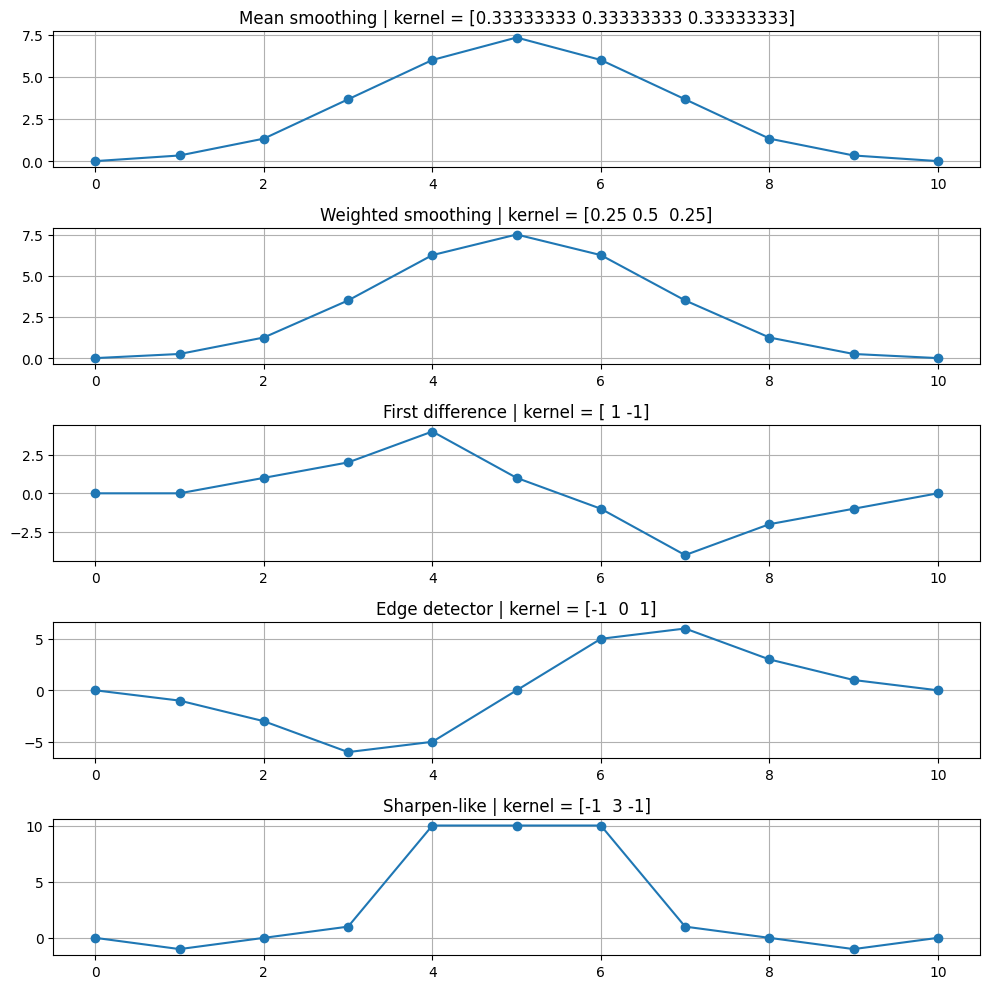

In [41]:
kernels = {
    'Mean smoothing': np.array([1/3, 1/3, 1/3]),
    'Weighted smoothing': np.array([0.25, 0.5, 0.25]),
    'First difference': np.array([1, -1]),
    'Edge detector': np.array([-1, 0, 1]),
    'Sharpen-like': np.array([-1, 3, -1])
}

plt.figure(figsize=(10, 10))
for i, (name, k) in enumerate(kernels.items(), start=1):
    y = np.convolve(x, k, mode='same')
    plt.subplot(len(kernels), 1, i)
    plt.plot(y, marker='o')
    plt.title(f'{name} | kernel = {k}')
    plt.grid(True)
plt.tight_layout()
plt.show()

### How to interpret these kernels

**Mean smoothing**
- reduces local noise
- preserves broad trends

**Weighted smoothing**
- still smooths the signal
- gives more influence to the center point

**First difference**
- estimates local change
- positive values indicate increase
- negative values indicate decrease

**Edge detector**
- responds to rapid changes across a wider local region
- often highlights transitions or boundaries

**Sharpen-like kernel**
- emphasizes local peaks relative to neighbors


## Other Examples

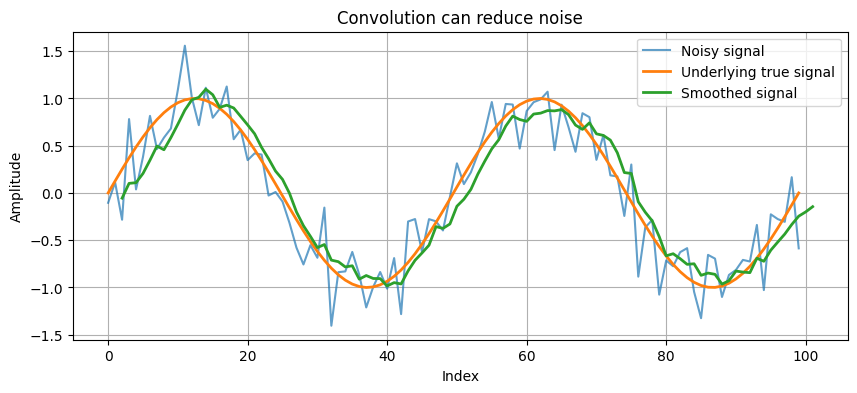

In [47]:
np.random.seed(2)
x_smooth_true = np.sin(np.linspace(0, 4*np.pi, 100))
noise = np.random.normal(scale=0.25, size=100)
x_noisy = x_smooth_true + noise

smoother = np.ones(5) / 5
y_noisy_smooth = np.convolve(x_noisy, smoother, mode='same')

plt.figure(figsize=(10, 4))
plt.plot(x_noisy, label='Noisy signal', alpha=0.7)
plt.plot(x_smooth_true, label='Underlying true signal', linewidth=2)
plt.plot(np.arange(2, 2+len(y_noisy_smooth)), y_noisy_smooth, label='Smoothed signal', linewidth=2)
plt.title('Convolution can reduce noise')
plt.xlabel('Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

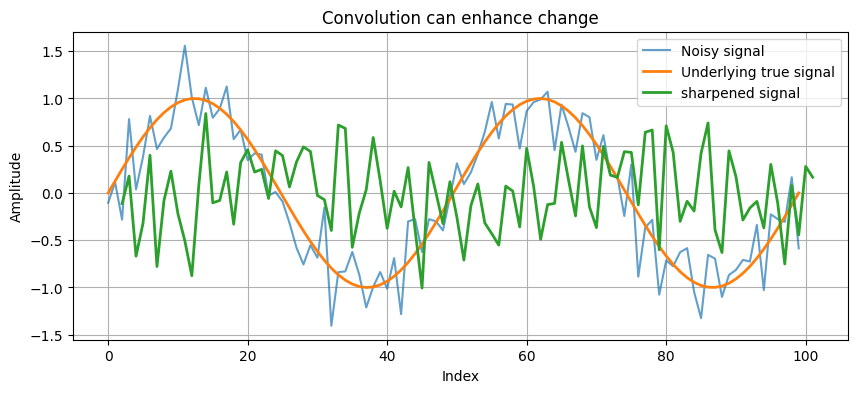

In [49]:
np.random.seed(2)
x_smooth_true = np.sin(np.linspace(0, 4*np.pi, 100))
noise = np.random.normal(scale=0.25, size=100)
x_noisy = x_smooth_true + noise

sharpener = np.array([-1,0,1])
y_noisy_smooth = np.convolve(x_noisy, sharpener, mode='same')

plt.figure(figsize=(10, 4))
plt.plot(x_noisy, label='Noisy signal', alpha=0.7)
plt.plot(x_smooth_true, label='Underlying true signal', linewidth=2)
plt.plot(np.arange(2, 2+len(y_noisy_smooth)), y_noisy_smooth, label='sharpened signal', linewidth=2)
plt.title('Convolution can enhance change')
plt.xlabel('Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

## From signal processing to neural networks

So far, we **chose the kernel values ourselves**.

Examples:
- mean smoothing: `[1/3, 1/3, 1/3]`
- edge detector: `[-1, 0, 1]`

However, similar to how we used data to learn the weights $\omega_i$ of a linear model, or an artificial neural network. We can also use data to learn the optimal kernels to process the data.

In a **convolutional neural network**, the kernel values are not manually chosen.
Instead, they are **learned from data** during training.

That means the model discovers which local patterns are useful for solving the task.